In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import shutil

import os
from time import perf_counter

qpy_dir = '/Net/Groups/BSI/work_scratch/ppapastefanou/src/QPy'
sys.path.append(qpy_dir)


from src.postprocessing.py.qnc_defintions import Output_format
from src.postprocessing.py.qnc_output_parser import QNC_output_parser
from src.postprocessing.py.qnc_ncdf_reader import QNC_ncdf_reader


In [8]:

RTOBSPATH = "/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/eval_processed"

df_sap = pd.read_csv(os.path.join(RTOBSPATH, "Sapflow2023.csv"))
df_sap['date'] = pd.to_datetime(df_sap['date'])
df_sap

,date,J0.1,J0.25,J0.5,J0.75,J0.9
0,2023-05-01 22:00:00,-1.953358,0.182093,2.507303,3.202199,4.340077
1,2023-05-01 22:30:00,-2.044817,0.263381,1.999431,3.005463,3.961681
2,2023-05-01 23:00:00,-1.993363,0.157446,1.737801,2.558568,3.460054
3,2023-05-01 23:30:00,-1.823605,0.202846,1.799361,2.574223,3.387077
4,2023-05-02 00:00:00,-1.794785,0.172579,1.707021,2.521190,3.201836
...,...,...,...,...,...,...
9005,2023-11-05 12:30:00,-6.002791,-3.859052,-1.728607,-1.219486,6.302652
9006,2023-11-05 13:00:00,-5.760715,-3.632049,-1.807565,-1.385264,6.107093
9007,2023-11-05 13:30:00,-5.694127,-3.465580,-1.854939,-1.445547,6.013385
9008,2023-11-05 14:00:00,-5.252289,-2.739170,-1.791773,-1.219486,6.660567


In [9]:
import matplotlib.pyplot as plt

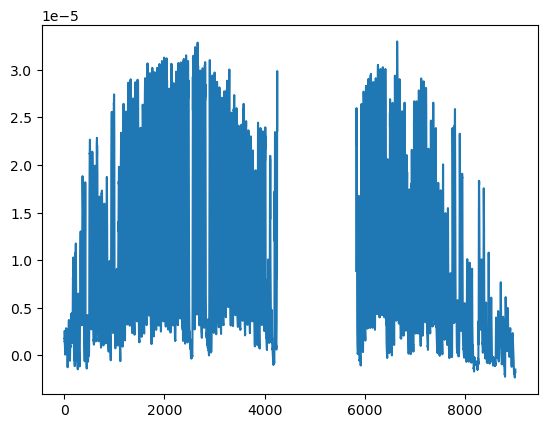

In [12]:
plt.plot(df_sap["J0.5"] * 5/5000 / 1000)

In [17]:
setup_root_path = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/QPy/jsbach_spq/30_run_transient_slurm_array_mort_hyd_fail_mort/output/609"
parser = QNC_output_parser(setup_root_path)
parser.Read()
output = parser.Available_outputs['fluxnetdata']
nc_output = QNC_ncdf_reader(setup_root_path,
                                        output.Categories,
                                        output.Identifier,
                                        output.Time_resolution
                                        )

nc_output.Parse_env_and_variables()
nc_output.Read_all_1D()
nc_output.Close()

In [19]:
df_mod_hyd = nc_output.Datasets_1D['PHYD']
df_merge = pd.merge(df_mod_hyd, df_sap, on='date', how='inner')   

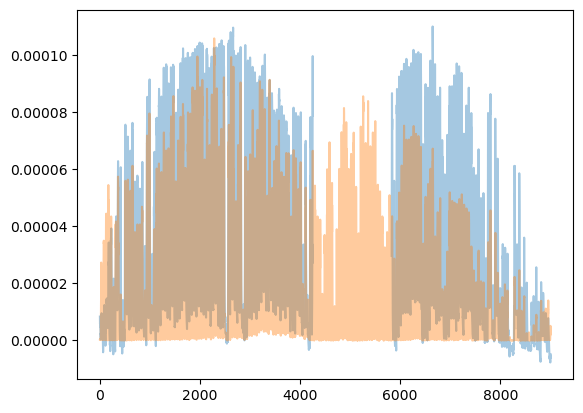

In [34]:
plt.plot(df_merge["J0.5"] * 5.0/1500 / 1000, alpha = 0.4)
plt.plot(df_merge["stem_flow_avg"], alpha = 0.4)

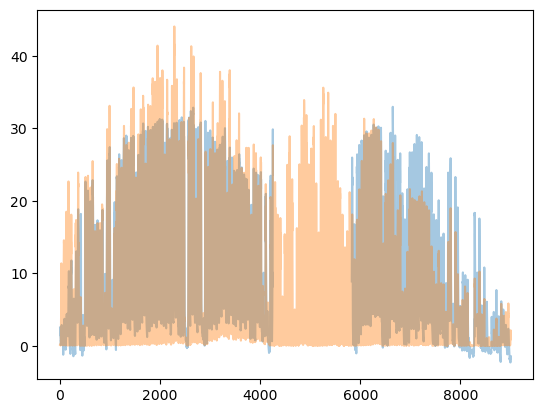

In [40]:
plt.plot(df_merge["J0.5"], alpha = 0.4)
plt.plot(df_merge["stem_flow_avg"] /6.0*2500 *1000, alpha = 0.4)

In [ ]:
10 * 150/5000